# DBSCAN Clustering sobre Eventos Tácticos (PCA Space)

Este notebook realiza el proceso de clusterización basado en densidad (DBSCAN) para encontrar fronteras naturales en los eventos tácticos, separar la señal del ruido estocástico y validar los resultados paramétricos.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from itertools import product

sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams['figure.dpi'] = 120

## 1. Carga de Datos

In [12]:
df_raw = pd.read_parquet('../../data/features/tactical_events_v3.parquet')
df_pca = pd.read_parquet('../../data/features/pca_scores.parquet')
X_pca = df_pca.filter(like='PC').values

print(f"Dimensiones cargadas: {X_pca.shape}")

Dimensiones cargadas: (643, 15)


## 2. DBSCAN Parameter Sweep

Para cumplir con el requerimiento técnico, iteraremos sobre múltiples combinaciones de `eps` y `min_samples`.

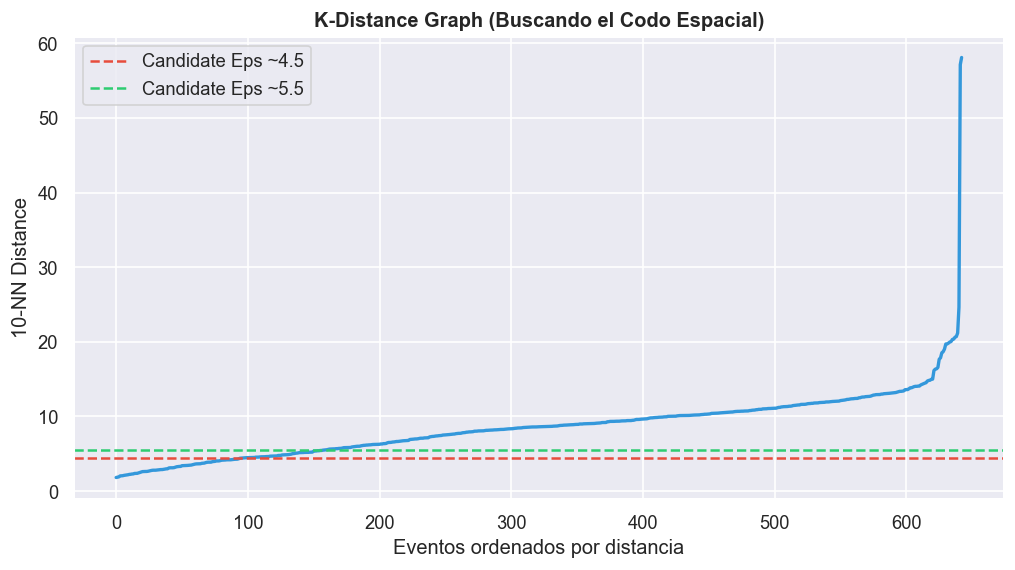

In [13]:
# 2.1 Encontrar un baseline de eps usando k-dist graph
min_samples_baseline = 10
neighbors = NearestNeighbors(n_neighbors=min_samples_baseline)
neighbors_fit = neighbors.fit(X_pca)
distances, indices = neighbors_fit.kneighbors(X_pca)
distances = np.sort(distances[:, min_samples_baseline-1], axis=0)

plt.figure(figsize=(10, 5))
plt.plot(distances, color='#3498db', linewidth=2)
plt.title('K-Distance Graph (Buscando el Codo Espacial)', fontweight='bold')
plt.ylabel(f'{min_samples_baseline}-NN Distance')
plt.xlabel('Eventos ordenados por distancia')
plt.axhline(y=4.5, color='#e74c3c', linestyle='--', label='Candidate Eps ~4.5')
plt.axhline(y=5.5, color='#2ecc71', linestyle='--', label='Candidate Eps ~5.5')
plt.legend()
plt.show()

In [14]:
# 2.2 Barrido paramétrico (Sweep)
eps_values = np.arange(3.5, 7.5, 0.5)
min_samples_values = [5, 10, 15, 20]

results = []
for eps, min_s in product(eps_values, min_samples_values):
    db = DBSCAN(eps=eps, min_samples=min_s)
    labels = db.fit_predict(X_pca)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    noise_ratio = list(labels).count(-1) / len(labels)
    sil_score = -1
    if n_clusters > 1:
        mask = labels != -1
        if len(set(labels[mask])) > 1:
            sil_score = silhouette_score(X_pca[mask], labels[mask])
    results.append({'Eps': eps, 'Min_Samples': min_s, 'Clusters': n_clusters, 'Noise_Ratio': noise_ratio, 'Silhouette': sil_score})

df_sweep = pd.DataFrame(results)
display(df_sweep.sort_values('Silhouette', ascending=False).head(10))

,Eps,Min_Samples,Clusters,Noise_Ratio,Silhouette
2,3.5,15,2,0.931571,0.646077
1,3.5,10,4,0.880249,0.637944
7,4.0,20,2,0.922240,0.618123
6,4.0,15,3,0.883359,0.586461
11,4.5,20,2,0.906687,0.548598
0,3.5,5,11,0.785381,0.526289
5,4.0,10,7,0.800933,0.500502
10,4.5,15,4,0.841369,0.473952
18,5.5,15,3,0.723173,0.457206
15,5.0,20,4,0.822706,0.454249


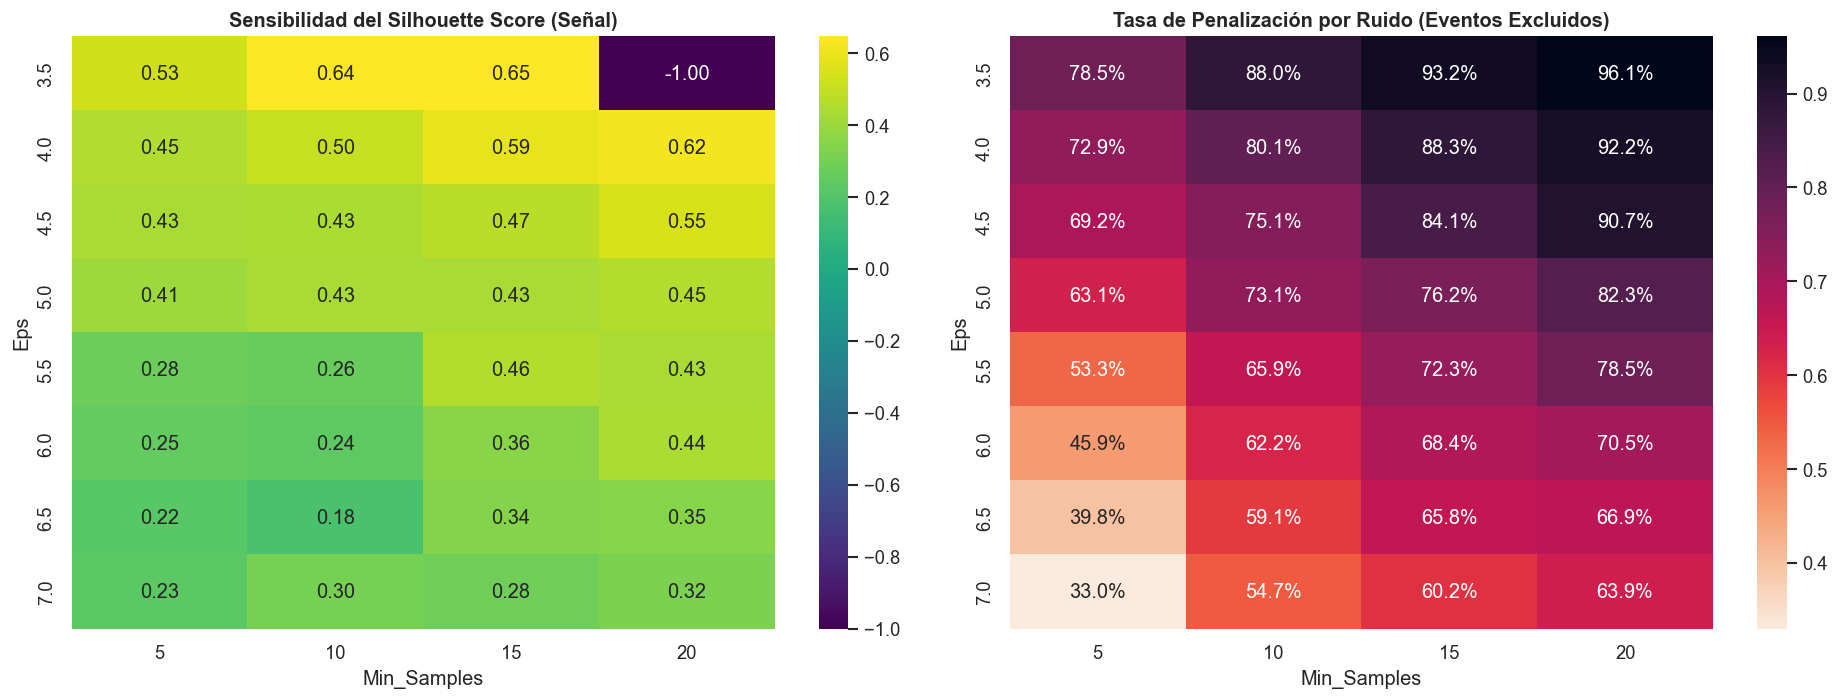

In [15]:
# 2.3 Visualización del Barrido (Heatmaps)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

pivot_sil = df_sweep.pivot(index='Eps', columns='Min_Samples', values='Silhouette')
sns.heatmap(pivot_sil, annot=True, cmap='viridis', ax=axes[0], fmt=".2f")
axes[0].set_title('Sensibilidad del Silhouette Score (Señal)', fontweight='bold')

pivot_noise = df_sweep.pivot(index='Eps', columns='Min_Samples', values='Noise_Ratio')
sns.heatmap(pivot_noise, annot=True, cmap='rocket_r', ax=axes[1], fmt=".1%")
axes[1].set_title('Tasa de Penalización por Ruido (Eventos Excluidos)', fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Modelo Final y Validación (Validation Table)

In [16]:
# Modelo Óptimo Elegido
BEST_EPS = 5.0
BEST_MIN_S = 10

db_final = DBSCAN(eps=BEST_EPS, min_samples=BEST_MIN_S)
df_pca['dbscan_cluster'] = db_final.fit_predict(X_pca)

mask_signal = df_pca['dbscan_cluster'] != -1
X_signal = X_pca[mask_signal]
labels_signal = df_pca.loc[mask_signal, 'dbscan_cluster']

val_silhouette = silhouette_score(X_signal, labels_signal)
val_davies = davies_bouldin_score(X_signal, labels_signal)
noise_pct = (~mask_signal).mean() * 100

val_table = pd.DataFrame({
    'Metric': ['Silhouette Score (Signal)', 'Davies-Bouldin', 'Noise Ratio (%)', 'Core Clusters Found'],
    'Value': [round(val_silhouette, 3), round(val_davies, 3), round(noise_pct, 1), len(set(labels_signal))]
})
display(val_table)

,Metric,Value
0,Silhouette Score (Signal),0.433
1,Davies-Bouldin,0.816
2,Noise Ratio (%),73.100
3,Core Clusters Found,5.000


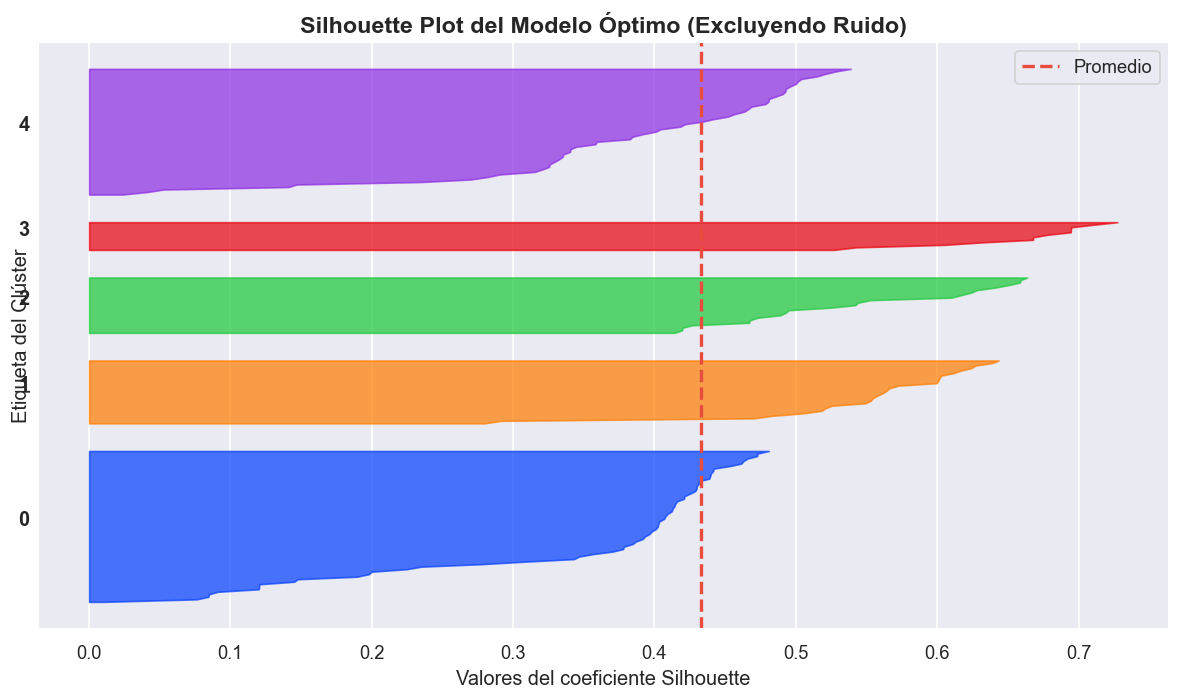

In [17]:
from sklearn.metrics import silhouette_samples

if len(set(labels_signal)) > 1:
    sample_silhouette_values = silhouette_samples(X_signal, labels_signal)
    
    fig, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    y_lower = 10
    
    for i, c in enumerate(sorted(set(labels_signal))):
        ith_cluster_silhouette_values = sample_silhouette_values[labels_signal == c]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        color = sns.color_palette('bright')[i]
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.7)
        
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(c), fontweight='bold')
        y_lower = y_upper + 10
        
    ax1.set_title("Silhouette Plot del Modelo Óptimo (Excluyendo Ruido)", fontweight='bold', fontsize=14)
    ax1.set_xlabel("Valores del coeficiente Silhouette")
    ax1.set_ylabel("Etiqueta del Clúster")
    
    # Linea vertical para el promedio de todos los valores
    ax1.axvline(x=val_silhouette, color="#e74c3c", linestyle="--", linewidth=2, label='Promedio')
    ax1.set_yticks([])
    ax1.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No hay suficientes clústeres de señal para graficar el Silhouette Plot.")

## 4. Visualización Avanzada de Resultados

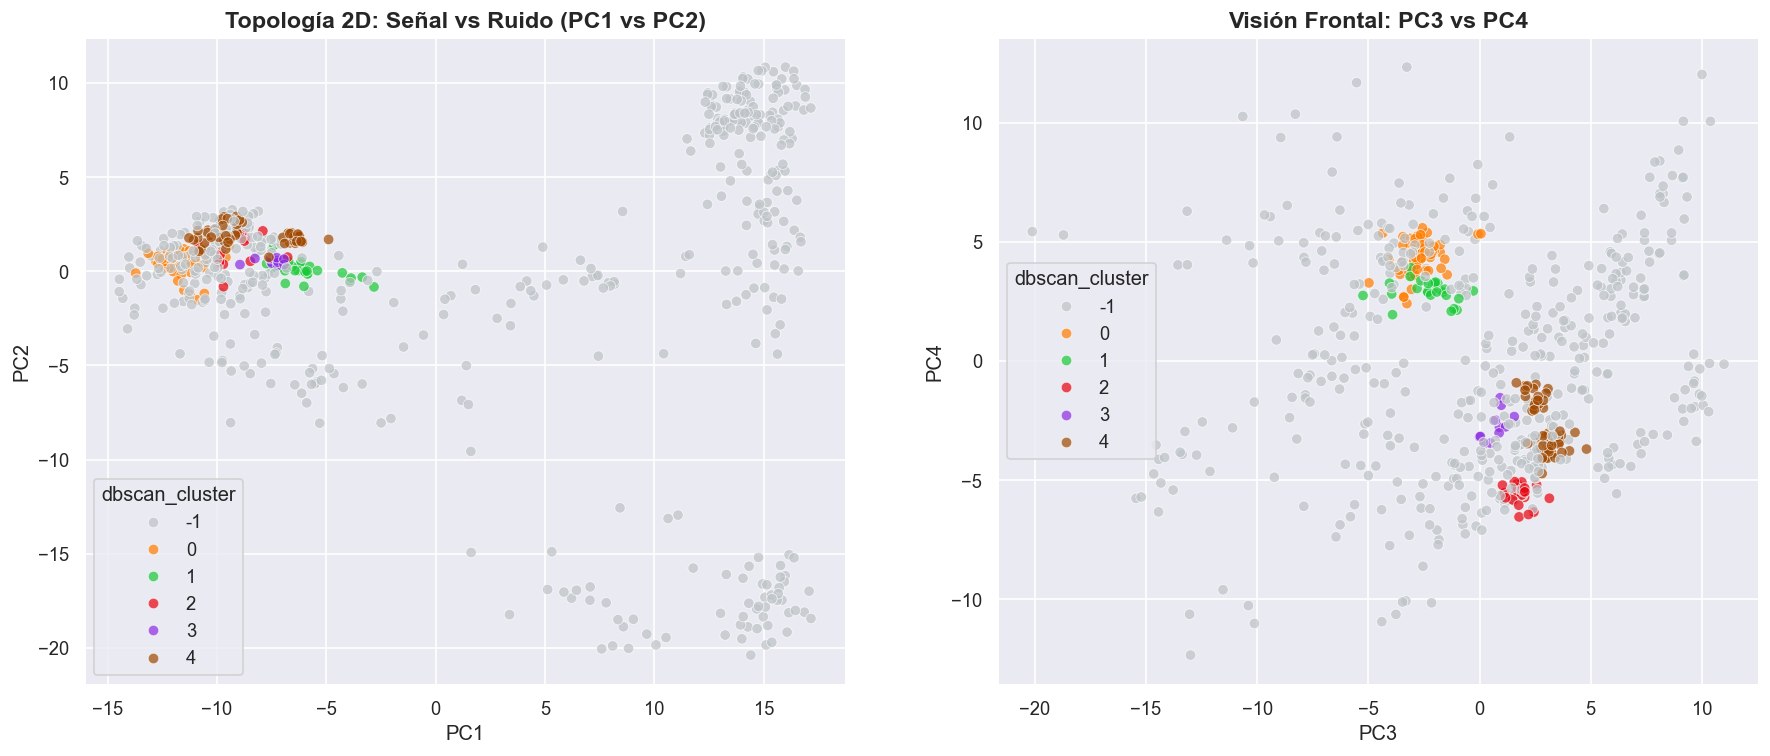

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Crear paleta dinámica, forzando al ruido (-1) a ser negro/gris translúcido
unique_clusters = sorted(df_pca['dbscan_cluster'].unique())
palette = {c: sns.color_palette('bright')[i] for i, c in enumerate(unique_clusters) if c != -1}
palette[-1] = '#bdc3c7' # Ruido

sns.scatterplot(x='PC1', y='PC2', hue='dbscan_cluster', data=df_pca, 
                palette=palette, ax=axes[0], alpha=0.7, s=40)
axes[0].set_title('Topología 2D: Señal vs Ruido (PC1 vs PC2)', fontweight='bold', fontsize=14)

sns.scatterplot(x='PC3', y='PC4', hue='dbscan_cluster', data=df_pca, 
                palette=palette, ax=axes[1], alpha=0.7, s=40)
axes[1].set_title('Visión Frontal: PC3 vs PC4', fontweight='bold', fontsize=14)

plt.show()

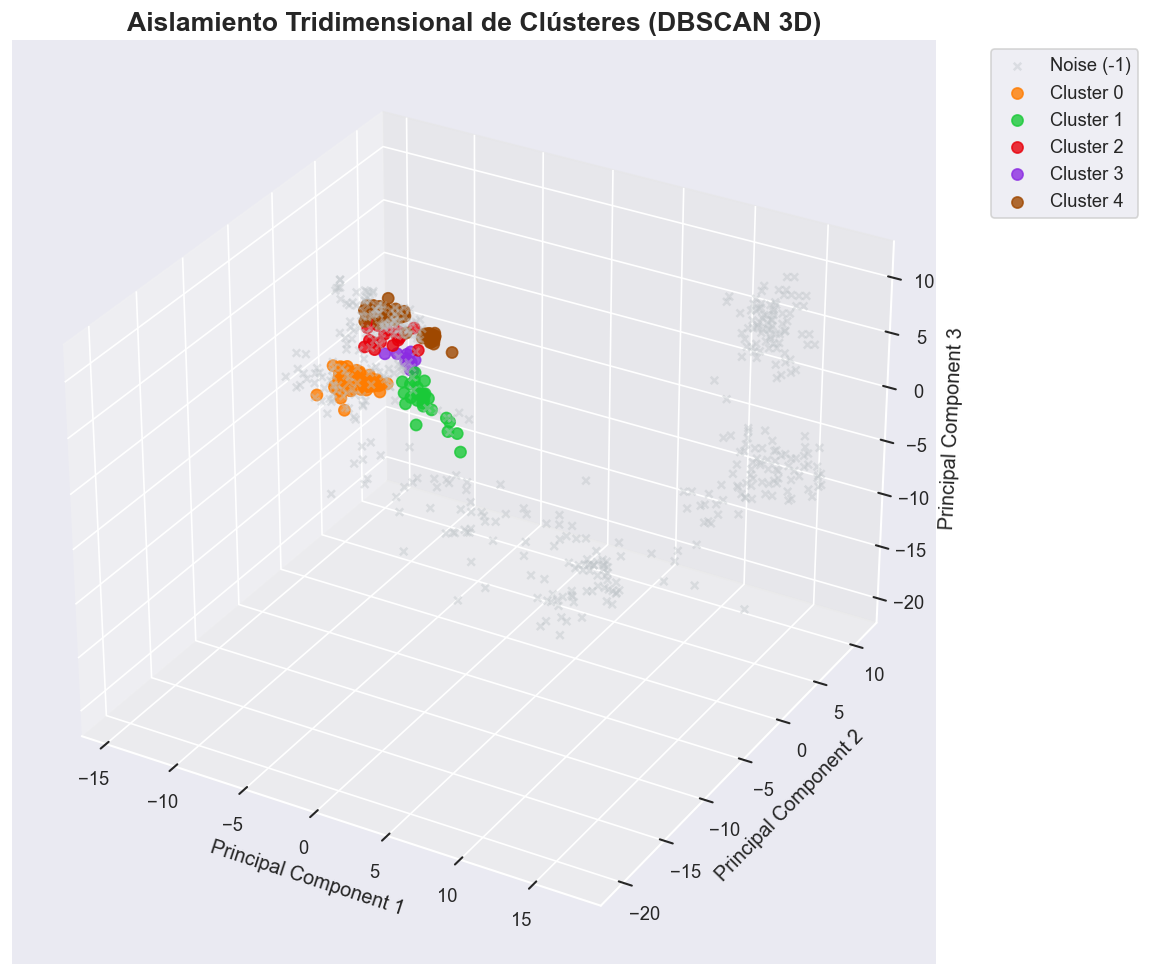

In [19]:
fig = plt.figure(figsize=(14, 10))
ax = fig.add_subplot(111, projection='3d')

for cluster_label in unique_clusters:
    subset = df_pca[df_pca['dbscan_cluster'] == cluster_label]
    color = palette[cluster_label]
    alpha = 0.4 if cluster_label == -1 else 0.8
    marker = 'x' if cluster_label == -1 else 'o'
    size = 20 if cluster_label == -1 else 45
    
    ax.scatter(
        subset['PC1'], subset['PC2'], subset['PC3'],
        label=f'Cluster {cluster_label}' if cluster_label != -1 else 'Noise (-1)',
        color=color, alpha=alpha, s=size, marker=marker
    )

ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')
ax.set_title('Aislamiento Tridimensional de Clústeres (DBSCAN 3D)', fontweight='bold', fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 5. Failure Analysis (Perfil del Ruido vs Señal)

C:\Users\User\AppData\Local\Temp\ipykernel_12088\2655851444.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Is_Noise', y='att_st_speed_mean', data=df_raw, ax=axes[0], palette='pastel')
C:\Users\User\AppData\Local\Temp\ipykernel_12088\2655851444.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Is_Noise', y='def_lap_duration_mean', data=df_raw, ax=axes[1], palette='pastel')


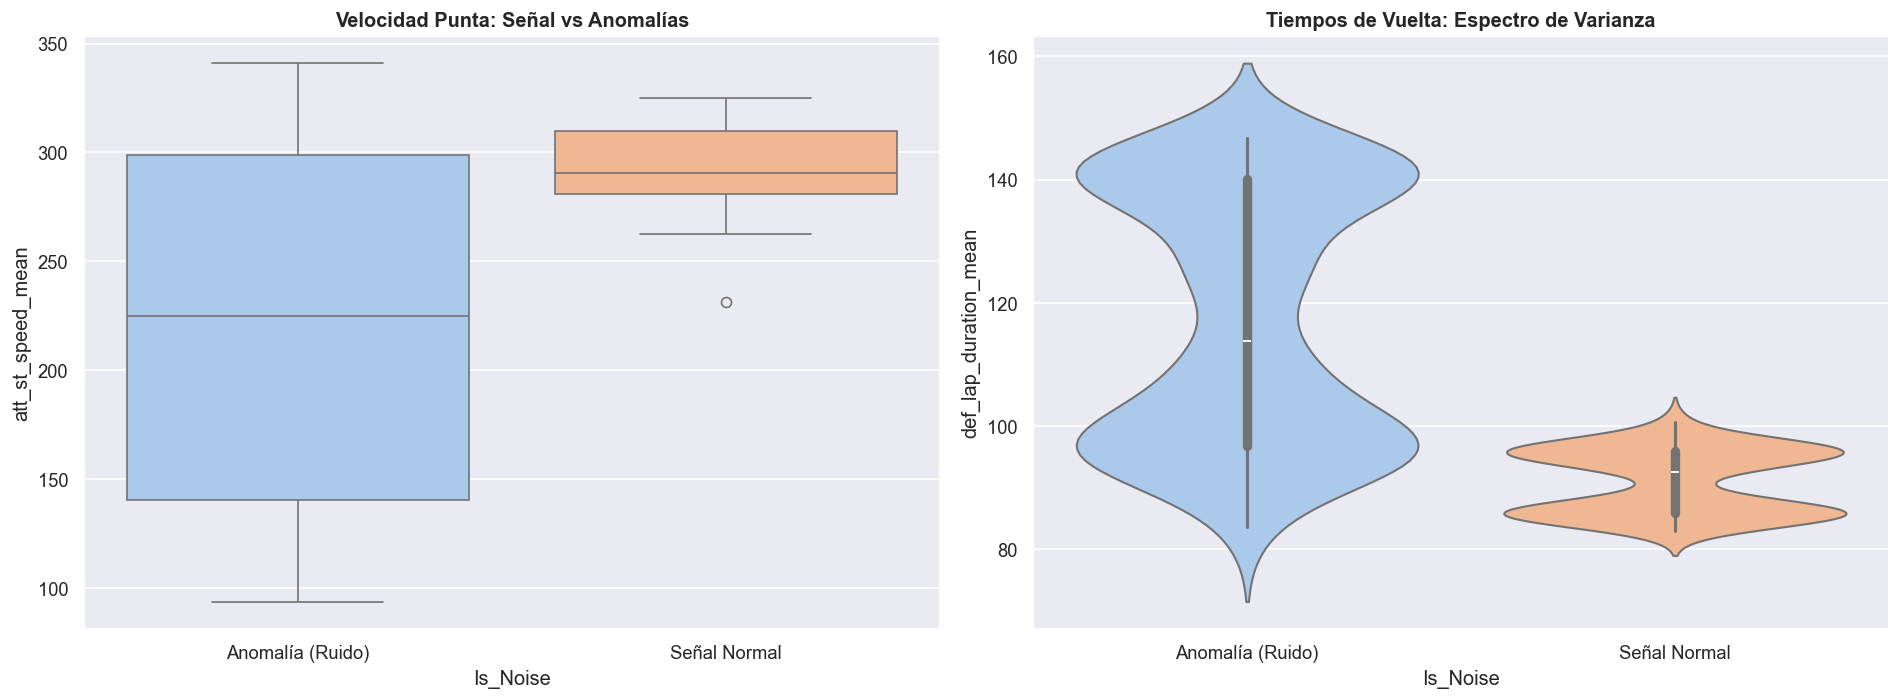

In [20]:
df_raw['Is_Noise'] = np.where(df_pca['dbscan_cluster'] == -1, 'Anomalía (Ruido)', 'Señal Normal')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Comparando velocidades (Si existen)
if 'att_st_speed_mean' in df_raw.columns:
    df_raw['att_st_speed_mean'] = pd.to_numeric(df_raw['att_st_speed_mean'], errors='coerce')
    sns.boxplot(x='Is_Noise', y='att_st_speed_mean', data=df_raw, ax=axes[0], palette='pastel')
    axes[0].set_title('Velocidad Punta: Señal vs Anomalías', fontweight='bold')

if 'def_lap_duration_mean' in df_raw.columns:
    df_raw['def_lap_duration_mean'] = pd.to_numeric(df_raw['def_lap_duration_mean'], errors='coerce')
    sns.violinplot(x='Is_Noise', y='def_lap_duration_mean', data=df_raw, ax=axes[1], palette='pastel')
    axes[1].set_title('Tiempos de Vuelta: Espectro de Varianza', fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Exportar resultados 
df_pca.to_parquet('../../data/features/dbscan_clusters.parquet', index=False)
print("Resultados espaciales listos para Machine Learning exportados en dbscan_clusters.parquet")

Resultados espaciales listos para Machine Learning exportados en dbscan_clusters.parquet
